# Experiment 6: Clustering — K-Means

**Description:**
Implement the K-Means clustering algorithm **from scratch** (no library clustering
functions) on the Bitcoin case-study dataset. Group trading days into market regimes
using two dimensions, visualise the resulting clusters, and evaluate the clustering
with a performance matrix.

**Case study:** *Predicting Trends and Uncovering Patterns in Bitcoin Price Movement Using Data Mining Techniques*

**Deliverables:**
- Python code (K-Means written without inbuilt clustering functions)
- Cluster visualisation — graphical representation
- Cluster analysis report
- Performance matrix

**Note on libraries:** `pandas` / `numpy` are used only for data handling and arithmetic,
and `matplotlib` / `seaborn` only for plotting. Every part of the clustering itself —
initialisation, distance computation, assignment, centroid update, convergence test,
SSE, silhouette coefficient and Davies–Bouldin index — is implemented manually in this
notebook. `sklearn.cluster` is never imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style (same conventions as Experiment 5)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

import os, warnings
warnings.filterwarnings('ignore')
OUT = "exp6_outputs"
os.makedirs(OUT, exist_ok=True)

RNG = np.random.default_rng(42)   # fixed seed so the run is reproducible

## 1. Data Loading and Feature Selection

The clustering is performed on the cleaned dataset produced in Experiment 4
(`btc_cleaned.csv`). Two dimensions are used, both expressed as percentages so that
a day in 2011 (BTC around $0.50) and a day in 2026 (BTC around $70,000) are directly
comparable:

| Axis | Feature | Meaning |
|------|---------|---------|
| x | `daily_pct_change` = (close - open) / open x 100 | **direction and size** of the day's move |
| y | `range_pct` = (high - low) / open x 100 | **intraday swing**, i.e. how turbulent the day was |

Together these two features describe *what kind of trading day* it was, which is exactly
the market-regime grouping the case study asks for.

In [2]:
df = pd.read_csv('btc_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])

# Feature engineering: scale-free intraday range
df['range_pct'] = df['daily_range'] / df['open'] * 100

FEATURES = ['daily_pct_change', 'range_pct']
full = df[['date', 'halving_era', 'close'] + FEATURES].dropna().reset_index(drop=True)

print("Rows in cleaned dataset :", len(full))
print("Date range              :", full['date'].min().date(), "to", full['date'].max().date())
print()
print(full[FEATURES].describe().round(3))
full.head()

Rows in cleaned dataset : 5534
Date range              : 2011-02-01 to 2026-03-27

       daily_pct_change  range_pct
count          5534.000   5534.000
mean              0.340      5.920
std               6.726      8.298
min             -57.206      0.000
25%              -1.330      2.512
50%               0.093      4.069
75%               1.778      6.668
max             336.839    378.716


,date,halving_era,close,daily_pct_change,range_pct
0,2011-02-01,Genesis Era (50 BTC/block),0.700,34.615385,63.461538
1,2011-02-02,Genesis Era (50 BTC/block),0.716,2.285714,10.000000
2,2011-02-03,Genesis Era (50 BTC/block),0.690,-3.631285,13.952514
3,2011-02-04,Genesis Era (50 BTC/block),0.811,17.536232,30.434783
4,2011-02-05,Genesis Era (50 BTC/block),0.920,13.440197,13.440197


## 2. Outlier Handling

K-Means minimises squared distance, so a single very distant point can pull an entire
centroid towards itself and waste a cluster on one day. The dataset contains exactly that
problem: the Mt. Gox collapse week of February 2014 includes a day with a **+336% change and
a 379% intraday range**.

The extreme days flagged by the Z-score method in Experiment 5 are therefore separated out
before clustering, using the same rule (|z| > 3 on either feature). They are not discarded from
the analysis - they are reported separately as a manually flagged **shock-day** group.

In [3]:
def zscore(matrix):
    return (matrix - matrix.mean(axis=0)) / matrix.std(axis=0)

Z_ALL = zscore(full[FEATURES].to_numpy(dtype=float))
outlier_mask = (np.abs(Z_ALL) > 3).any(axis=1)

shock_days = full[outlier_mask].copy()
data = full[~outlier_mask].reset_index(drop=True)

print(f"Shock days removed before clustering : {outlier_mask.sum()}  "
      f"({outlier_mask.sum() / len(full) * 100:.2f}% of the dataset)")
print(f"Days passed to K-Means               : {len(data)}")
print("\nShock days per year:")
print(shock_days['date'].dt.year.value_counts().sort_index().to_string())
print("\nTen most extreme shock days:")
print(shock_days.nlargest(10, 'range_pct')[['date', 'daily_pct_change', 'range_pct']]
      .to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

Shock days removed before clustering : 72  (1.30% of the dataset)
Days passed to K-Means               : 5462

Shock days per year:
date
2011    27
2012     6
2013    16
2014    14
2015     3
2017     3
2020     2
2021     1

Ten most extreme shock days:
      date  daily_pct_change  range_pct
2014-02-26            336.84     378.72
2014-02-22            129.11     173.78
2011-06-12             26.62     100.61
2014-02-16            -19.21      86.15
2013-04-10            -28.26      70.00
2013-04-12             -6.33      68.65
2011-02-01             34.62      63.46
2014-02-20            -57.21      62.09
2014-02-21             -0.32      61.20
2014-02-24            -43.90      59.65


## 3. Feature Scaling (manual z-score standardisation)

K-Means uses Euclidean distance, so a feature with a wider spread would dominate the
distance. `range_pct` is always positive and has a larger standard deviation than
`daily_pct_change`, so both columns are standardised to mean 0 and standard deviation 1:

$$z = \frac{x - \mu}{\sigma}$$

The standardisation is written out by hand (no `StandardScaler`). Clustering is done in
z-space; the final centroids are converted back to the original percentage units for
interpretation.

In [4]:
def zscore_standardise(matrix):
    """Manual z-score standardisation. Returns scaled matrix, means and std devs."""
    mu = matrix.mean(axis=0)
    sigma = matrix.std(axis=0)
    return (matrix - mu) / sigma, mu, sigma

def inverse_standardise(matrix, mu, sigma):
    """Convert z-space coordinates back into original percentage units."""
    return matrix * sigma + mu

X_raw = data[FEATURES].to_numpy(dtype=float)
X, MU, SIGMA = zscore_standardise(X_raw)

print("Original  means :", np.round(MU, 4), "   std devs :", np.round(SIGMA, 4))
print("Scaled    means :", np.round(X.mean(axis=0), 6), "   std devs :", np.round(X.std(axis=0), 6))
print("Scaled matrix shape:", X.shape)

Original  means : [0.2493 5.3514]    std devs : [3.7666 4.3746]
Scaled    means : [ 0. -0.]    std devs : [1. 1.]
Scaled matrix shape: (5462, 2)


## 4. K-Means Implemented From Scratch

The algorithm implemented below is exactly the one solved by hand in the writeup:

1. **Initialise** k centroids (k-means++ seeding, also written manually — it spreads the
   initial centroids out instead of picking them blindly, which reduces the chance of a
   bad local optimum).
2. **Assignment step** — assign every point to the nearest centroid using Euclidean distance
   $d(p, c) = \sqrt{(p_x - c_x)^2 + (p_y - c_y)^2}$.
3. **Update step** — move each centroid to the arithmetic mean of the points assigned to it.
4. **Repeat** 2–3 until the centroids stop moving (shift < tolerance) or `max_iter` is reached.

The objective being minimised is the **Sum of Squared Errors (SSE)**, also called inertia:

$$SSE = \sum_{i=1}^{k} \sum_{p \in C_i} \lVert p - c_i \rVert^2$$

In [5]:
def euclidean_distances(points, centroids):
    """Distance matrix of shape (n_points, k) — one row per point, one column per centroid."""
    diff = points[:, None, :] - centroids[None, :, :]      # (n, k, d)
    return np.sqrt((diff ** 2).sum(axis=2))

def assign_clusters(points, centroids):
    """Assignment step: index of the nearest centroid for every point."""
    return euclidean_distances(points, centroids).argmin(axis=1)

def update_centroids(points, labels, k, previous):
    """Update step: each centroid becomes the mean of its members (empty cluster keeps its old position)."""
    new = np.empty_like(previous)
    for i in range(k):
        members = points[labels == i]
        new[i] = members.mean(axis=0) if len(members) else previous[i]
    return new

def compute_sse(points, labels, centroids):
    """Sum of squared distances of every point to its own centroid."""
    return float(((points - centroids[labels]) ** 2).sum())

def kmeanspp_init(points, k, rng):
    """k-means++ seeding, written manually: each new centroid is drawn with probability
    proportional to its squared distance from the closest centroid already chosen."""
    centroids = [points[rng.integers(len(points))]]
    for _ in range(1, k):
        d2 = euclidean_distances(points, np.array(centroids)).min(axis=1) ** 2
        probs = d2 / d2.sum()
        centroids.append(points[rng.choice(len(points), p=probs)])
    return np.array(centroids)

def kmeans_fit(points, k, rng, max_iter=100, tol=1e-6, verbose=False):
    """Full K-Means loop. Returns centroids, labels, SSE, iterations used and the SSE trace."""
    centroids = kmeanspp_init(points, k, rng)
    trace = []
    labels = np.zeros(len(points), dtype=int)
    for it in range(1, max_iter + 1):
        labels = assign_clusters(points, centroids)                 # step 2
        new_centroids = update_centroids(points, labels, k, centroids)  # step 3
        shift = float(np.sqrt(((new_centroids - centroids) ** 2).sum(axis=1)).max())
        sse = compute_sse(points, labels, new_centroids)
        trace.append(sse)
        if verbose:
            sizes = np.bincount(labels, minlength=k)
            print(f"  iter {it:>2} | max centroid shift = {shift:9.6f} | SSE = {sse:11.2f} | sizes = {sizes.tolist()}")
        centroids = new_centroids
        if shift < tol:                                             # step 4: convergence
            break
    return centroids, labels, compute_sse(points, labels, centroids), it, trace

def kmeans_best_of(points, k, restarts, rng, verbose=False):
    """K-Means is sensitive to initialisation, so it is restarted and the lowest-SSE run kept."""
    best = None
    for r in range(restarts):
        centroids, labels, sse, iters, trace = kmeans_fit(points, k, rng)
        if verbose:
            print(f"  restart {r+1:>2}: SSE = {sse:11.2f}  ({iters} iterations)")
        if best is None or sse < best[2]:
            best = (centroids, labels, sse, iters, trace)
    return best

print("K-Means functions defined — no clustering library imported.")

K-Means functions defined — no clustering library imported.


## 5. Choosing the Number of Clusters

### 5.1 Elbow Method
K-Means is run for k = 1 … 8 and the SSE of each run is plotted. SSE always falls as k
grows, so the useful value of k is the "elbow" — the point after which extra clusters buy
very little extra compactness.

In [6]:
K_RANGE = range(1, 9)
elbow = []
for k in K_RANGE:
    _, _, sse, iters, _ = kmeans_best_of(X, k, restarts=5, rng=np.random.default_rng(42 + k))
    elbow.append(sse)
    print(f"k = {k}: SSE = {sse:11.2f}   ({iters} iterations in the best run)")

# Improvement contributed by each extra cluster
print("\nMarginal improvement in SSE:")
for i in range(1, len(elbow)):
    abs_drop = elbow[i-1] - elbow[i]
    pct_drop = abs_drop / elbow[i-1] * 100
    print(f"  k = {i} -> {i+1}: SSE falls by {abs_drop:8.1f}  ({pct_drop:4.1f}%)")

k = 1: SSE =    10924.00   (2 iterations in the best run)
k = 2: SSE =     7193.73   (9 iterations in the best run)
k = 3: SSE =     4148.94   (20 iterations in the best run)
k = 4: SSE =     3160.67   (22 iterations in the best run)


k = 5: SSE =     2319.82   (22 iterations in the best run)


k = 6: SSE =     1979.51   (24 iterations in the best run)
k = 7: SSE =     1666.48   (37 iterations in the best run)


k = 8: SSE =     1489.04   (34 iterations in the best run)

Marginal improvement in SSE:
  k = 1 -> 2: SSE falls by   3730.3  (34.1%)
  k = 2 -> 3: SSE falls by   3044.8  (42.3%)
  k = 3 -> 4: SSE falls by    988.3  (23.8%)
  k = 4 -> 5: SSE falls by    840.8  (26.6%)
  k = 5 -> 6: SSE falls by    340.3  (14.7%)
  k = 6 -> 7: SSE falls by    313.0  (15.8%)
  k = 7 -> 8: SSE falls by    177.4  (10.6%)


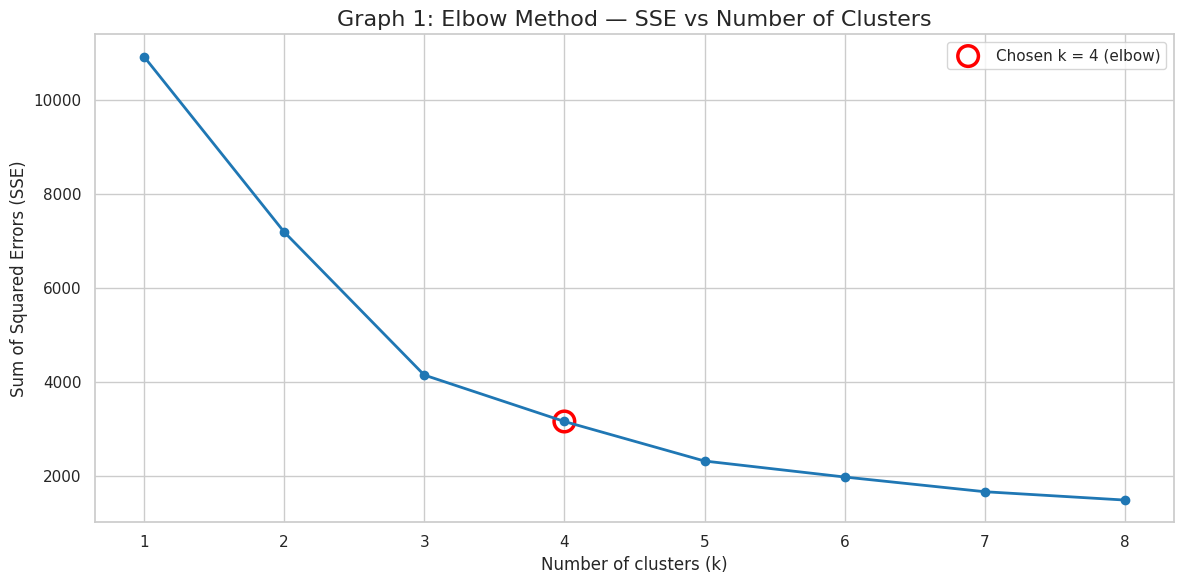

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(list(K_RANGE), elbow, marker='o', color='#1f77b4', linewidth=2)
plt.scatter([4], [elbow[3]], s=220, facecolors='none', edgecolors='red', linewidths=2.5,
            label='Chosen k = 4 (elbow)')
plt.title('Graph 1: Elbow Method — SSE vs Number of Clusters', fontsize=16)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/graph1_elbow.png", dpi=150)
plt.show()

### 5.2 Silhouette Analysis (implemented from scratch)

For a point *i*, let **a(i)** be its mean distance to the other points of its own cluster and
**b(i)** the smallest mean distance to any other cluster. The silhouette coefficient is

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1,\, 1]$$

A value near 1 means the point sits comfortably inside its cluster; near 0 means it sits on a
boundary. The mean over all points scores the clustering. Because this needs every pairwise
distance (O(n²)), it is computed on a random sample of 1,500 days — standard practice for
large datasets and enough for a stable estimate.

In [8]:
def silhouette_samples_manual(points, labels):
    """Per-point silhouette coefficient, computed without any library helper."""
    n = len(points)
    unique = np.unique(labels)
    dist = np.sqrt(((points[:, None, :] - points[None, :, :]) ** 2).sum(axis=2))
    s = np.zeros(n)
    for i in range(n):
        own = labels[i]
        same = (labels == own).copy()
        same[i] = False
        a = dist[i, same].mean() if same.any() else 0.0          # cohesion
        others = [dist[i, labels == o].mean()                    # separation
                  for o in unique if o != own and (labels == o).any()]
        if not others:                       # only one cluster present -> undefined
            s[i] = 0.0
            continue
        b = min(others)
        s[i] = 0.0 if max(a, b) == 0 else (b - a) / max(a, b)
    return s

def silhouette_score_manual(points, labels):
    return float(silhouette_samples_manual(points, labels).mean())

SAMPLE_N = 1500
sample_idx = np.random.default_rng(7).choice(len(X), SAMPLE_N, replace=False)
X_sample = X[sample_idx]

sil_scores = {}
for k in range(2, 7):
    centroids, labels, _, _, _ = kmeans_best_of(X, k, restarts=5, rng=np.random.default_rng(100 + k))
    sil_scores[k] = silhouette_score_manual(X_sample, labels[sample_idx])
    print(f"k = {k}: mean silhouette = {sil_scores[k]:.4f}")

k = 2: mean silhouette = 0.5473
k = 3: mean silhouette = 0.5825


k = 4: mean silhouette = 0.4742


k = 5: mean silhouette = 0.4840


k = 6: mean silhouette = 0.4416


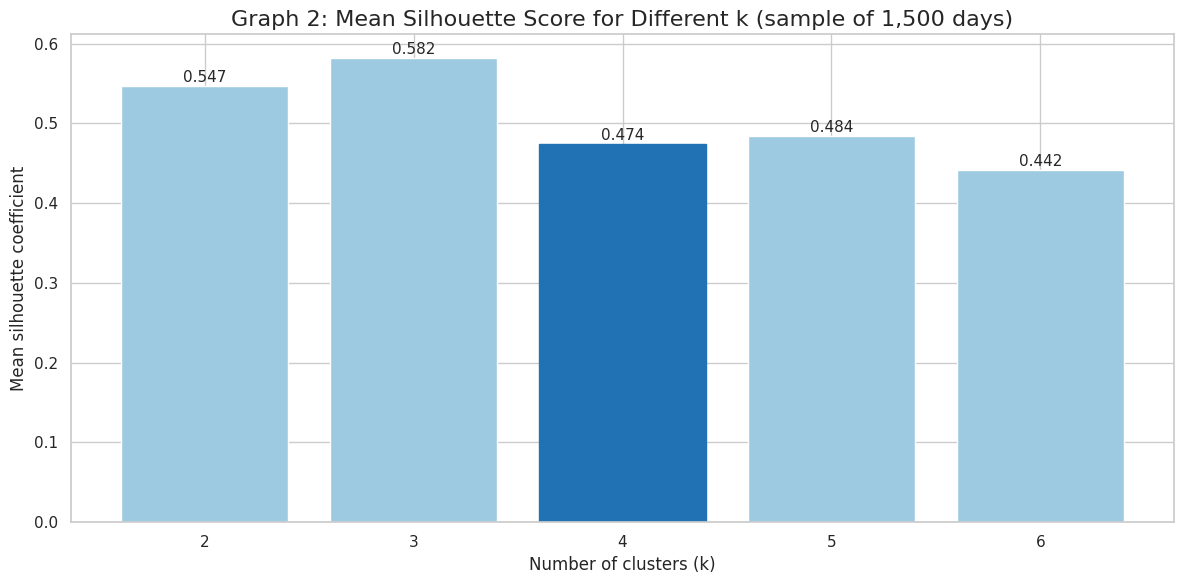

In [9]:
plt.figure(figsize=(12, 6))
ks, vals = list(sil_scores.keys()), list(sil_scores.values())
bars = plt.bar([str(k) for k in ks], vals, color=['#9ecae1'] * len(ks))
bars[ks.index(4)].set_color('#2171b5')
for k, v in zip(ks, vals):
    plt.text(str(k), v + 0.005, f"{v:.3f}", ha='center', fontsize=11)
plt.title('Graph 2: Mean Silhouette Score for Different k (sample of 1,500 days)', fontsize=16)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Mean silhouette coefficient', fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT}/graph2_silhouette_k.png", dpi=150)
plt.show()

## 6. Final Model — K-Means with k = 4

**Why k = 4.** The SSE curve bends at k = 4 (the marginal gain from the fifth cluster is much
smaller than the gains up to the fourth), and four clusters match the market regimes the case
study set out to find. The silhouette score is honest about the trade-off: k = 3 scores slightly
higher, because at k = 3 the turbulent days form one wide group. Splitting that group into
**volatile-up** and **volatile-down** days is exactly the distinction the case study needs for a
risk-alert system, so k = 4 is retained and the small drop in silhouette is accepted and reported.

The algorithm is restarted 10 times and the run with the lowest SSE is kept, because K-Means only
guarantees a local optimum.

In [10]:
K = 4
print("Restart search:")
centroids_z, labels, final_sse, iters, sse_trace = kmeans_best_of(
    X, K, restarts=10, rng=np.random.default_rng(2026), verbose=True)

print("\nConvergence log of a fresh run with the same settings:")
_, _, _, _, _ = kmeans_fit(X, K, np.random.default_rng(2026), verbose=True)

data['cluster'] = labels
centroids_raw = inverse_standardise(centroids_z, MU, SIGMA)

print(f"\nBest SSE (z-space): {final_sse:.2f}")
print("\nFinal centroids in original units:")
cent_table = pd.DataFrame(centroids_raw, columns=['daily_pct_change (%)', 'range_pct (%)'])
cent_table.insert(0, 'cluster', range(K))
cent_table['members'] = np.bincount(labels, minlength=K)
cent_table['share (%)'] = (cent_table['members'] / len(data) * 100).round(2)
cent_table.round(3)

Restart search:
  restart  1: SSE =     3218.81  (14 iterations)
  restart  2: SSE =     3160.67  (24 iterations)
  restart  3: SSE =     3160.71  (19 iterations)
  restart  4: SSE =     3160.65  (12 iterations)
  restart  5: SSE =     3160.71  (19 iterations)
  restart  6: SSE =     3218.87  (21 iterations)
  restart  7: SSE =     3160.71  (20 iterations)
  restart  8: SSE =     3218.87  (18 iterations)
  restart  9: SSE =     3160.71  (27 iterations)
  restart 10: SSE =     3218.87  (20 iterations)

Convergence log of a fresh run with the same settings:
  iter  1 | max centroid shift =  1.169619 | SSE =     3400.28 | sizes = [605, 3807, 946, 104]
  iter  2 | max centroid shift =  0.385848 | SSE =     3267.19 | sizes = [600, 3829, 889, 144]
  iter  3 | max centroid shift =  0.188557 | SSE =     3242.49 | sizes = [600, 3798, 898, 166]
  iter  4 | max centroid shift =  0.102728 | SSE =     3231.99 | sizes = [599, 3760, 924, 179]
  iter  5 | max centroid shift =  0.094945 | SSE =     322

,cluster,daily_pct_change (%),range_pct (%),members,share (%)
0,0,9.575,15.710,251,4.60
1,1,-0.479,3.284,3652,66.86
2,2,3.456,6.641,1097,20.08
3,3,-6.676,13.002,462,8.46


### 6.1 Naming the clusters

Each centroid is read as *"an average day of this type"*: the x-coordinate says which way the
day moved, the y-coordinate says how wide the swing was. The labels below are assigned from
those centroid coordinates after the model is fitted (K-Means itself is unsupervised — it
produces numbered clusters only).

In [11]:
order = np.argsort(centroids_raw[:, 1])          # rank clusters by turbulence (mean range %)

def name_cluster(rank, x):
    """Label a cluster from its centroid: rank on the turbulence axis + sign of the move."""
    if rank == 0:
        return 'Calm / Sideways'
    if rank == 1:
        return 'Mild Bullish Drift' if x > 0 else 'Mild Bearish Drift'
    return 'Volatile Bullish (Rally)' if x > 0 else 'Volatile Bearish (Sell-off)'

regime_names = {int(cl): name_cluster(rank, centroids_raw[cl, 0]) for rank, cl in enumerate(order)}
order_names = [regime_names[int(cl)] for cl in order]

data['regime'] = data['cluster'].map(regime_names)
cent_table['regime'] = cent_table['cluster'].map(regime_names)

print("Cluster -> regime mapping (ordered by average intraday range):")
for rank, cl in enumerate(order):
    print(f"  Cluster {cl}: centroid = ({centroids_raw[cl,0]:+6.2f}%, {centroids_raw[cl,1]:5.2f}%)"
          f"  ->  {regime_names[int(cl)]}")

cent_table[['cluster', 'regime', 'daily_pct_change (%)', 'range_pct (%)', 'members', 'share (%)']].round(3)

Cluster -> regime mapping (ordered by average intraday range):
  Cluster 1: centroid = ( -0.48%,  3.28%)  ->  Calm / Sideways
  Cluster 2: centroid = ( +3.46%,  6.64%)  ->  Mild Bullish Drift
  Cluster 3: centroid = ( -6.68%, 13.00%)  ->  Volatile Bearish (Sell-off)
  Cluster 0: centroid = ( +9.58%, 15.71%)  ->  Volatile Bullish (Rally)


,cluster,regime,daily_pct_change (%),range_pct (%),members,share (%)
0,0,Volatile Bullish (Rally),9.575,15.710,251,4.60
1,1,Calm / Sideways,-0.479,3.284,3652,66.86
2,2,Mild Bullish Drift,3.456,6.641,1097,20.08
3,3,Volatile Bearish (Sell-off),-6.676,13.002,462,8.46


## 7. Cluster Visualisation

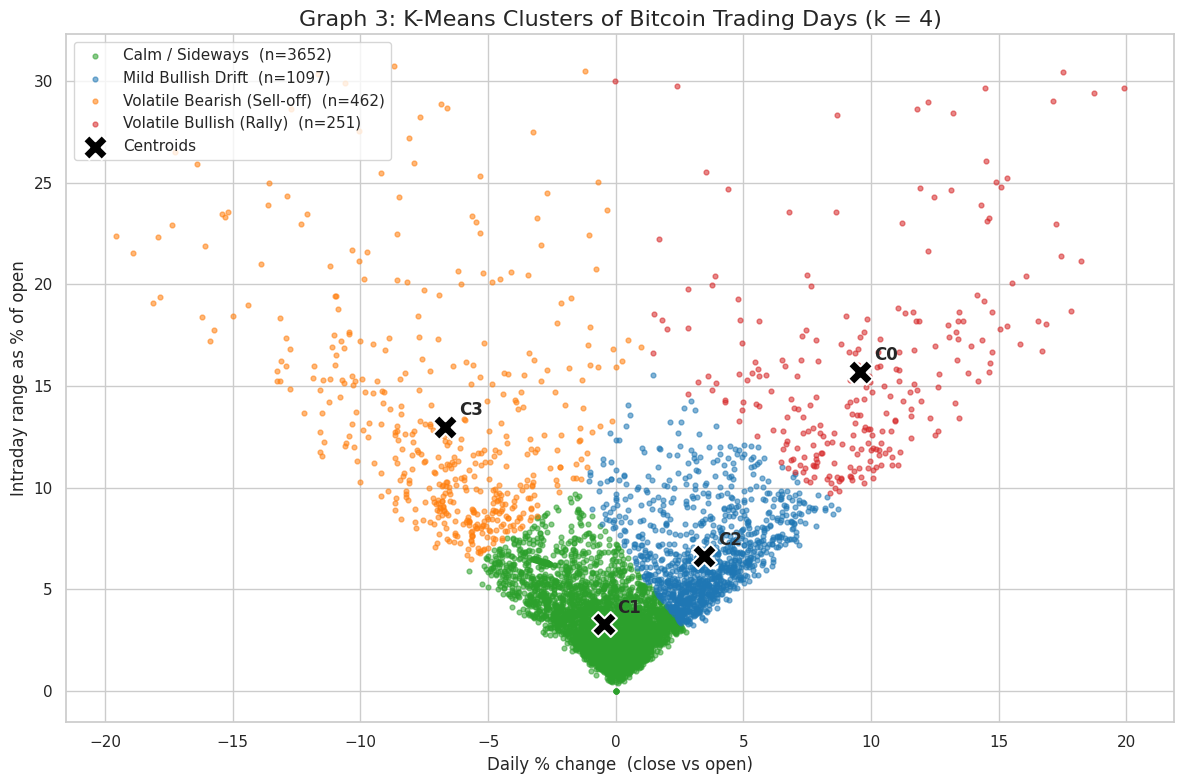

In [12]:
COLOURS = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']   # calm -> most turbulent
PALETTE = {regime_names[int(cl)]: COLOURS[rank] for rank, cl in enumerate(order)}

plt.figure(figsize=(12, 8))
for regime, colour in PALETTE.items():
    sub = data[data['regime'] == regime]
    plt.scatter(sub['daily_pct_change'], sub['range_pct'], s=12, alpha=0.55,
                color=colour, label=f"{regime}  (n={len(sub)})")
plt.scatter(centroids_raw[:, 0], centroids_raw[:, 1], marker='X', s=320,
            c='black', edgecolors='white', linewidths=1.5, zorder=6, label='Centroids')
for cl in range(K):
    plt.annotate(f"C{cl}", (centroids_raw[cl, 0], centroids_raw[cl, 1]),
                 textcoords="offset points", xytext=(10, 8), fontsize=12, fontweight='bold')
plt.title('Graph 3: K-Means Clusters of Bitcoin Trading Days (k = 4)', fontsize=16)
plt.xlabel('Daily % change  (close vs open)', fontsize=12)
plt.ylabel('Intraday range as % of open', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUT}/graph3_clusters_scatter.png", dpi=150)
plt.show()

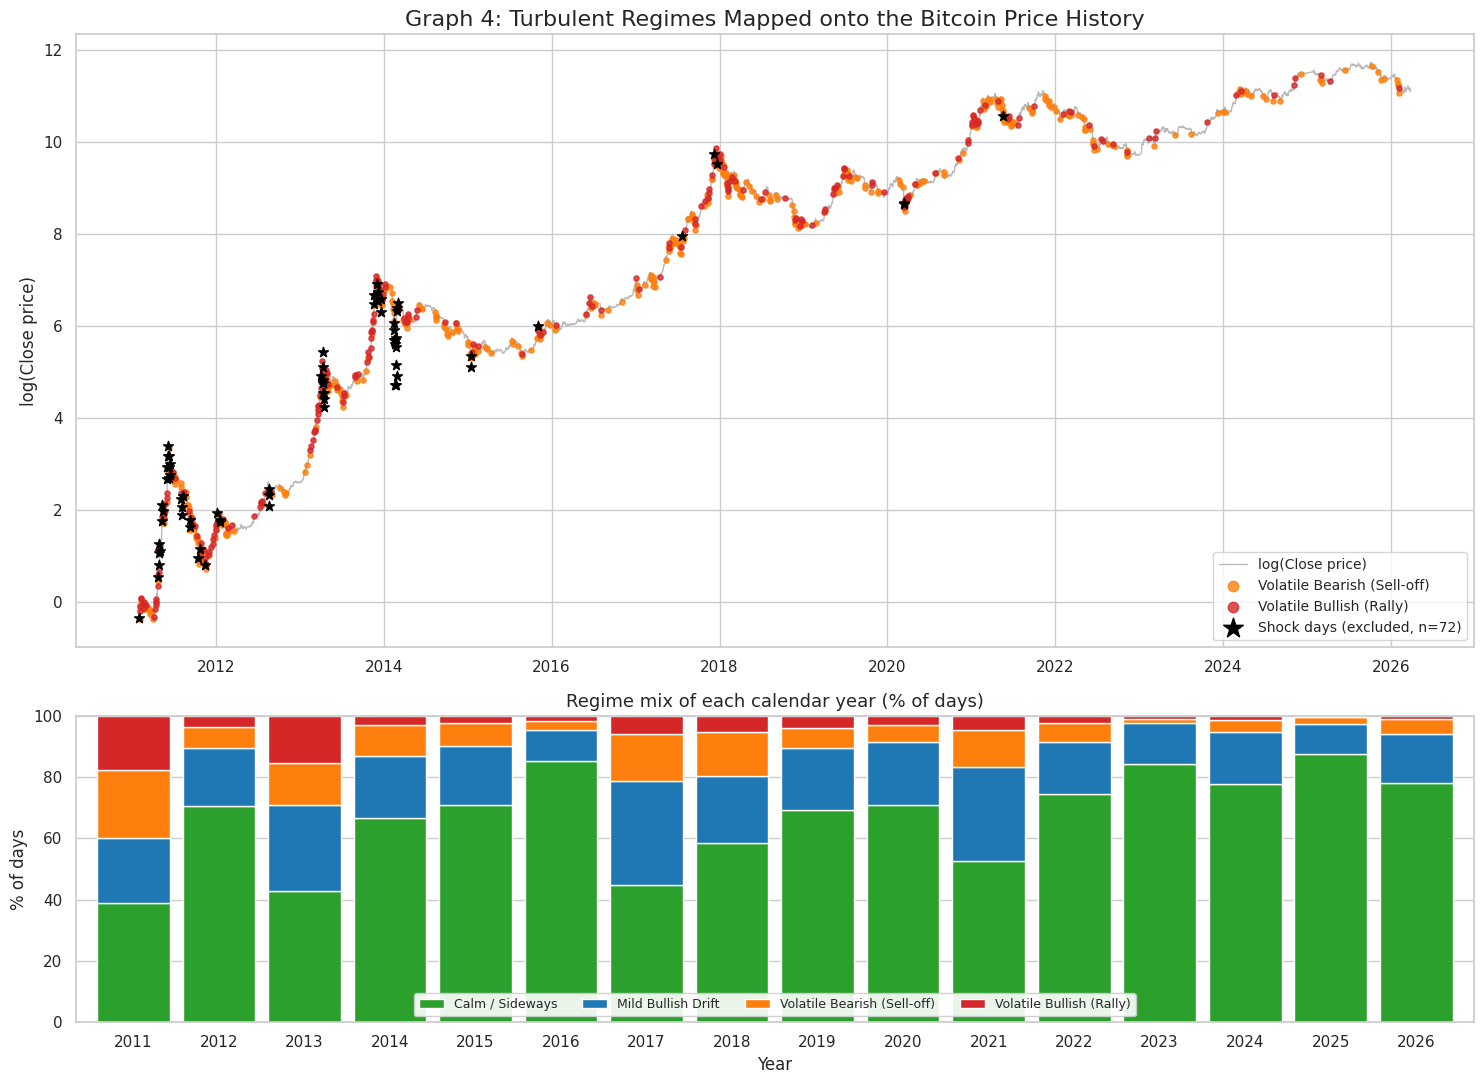

Share of turbulent days (sell-off + rally) per year:
date
2011    39.7
2012    10.6
2013    29.2
2014    13.1
2015     9.9
2016     4.6
2017    21.3
2018    19.7
2019    10.4
2020     8.5
2021    16.8
2022     8.5
2023     2.2
2024     5.2
2025     2.7
2026     5.8


In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 11), gridspec_kw={'height_ratios': [2, 1]})

# --- upper panel: price history with the turbulent regimes highlighted ---
ax1.plot(data['date'], np.log(data['close']), color='#bbbbbb', linewidth=1, zorder=1,
         label='log(Close price)')
for regime in order_names[2:]:                      # the two volatile clusters
    sub = data[data['regime'] == regime]
    ax1.scatter(sub['date'], np.log(sub['close']), s=14, alpha=0.8,
                color=PALETTE[regime], label=regime, zorder=2)
ax1.scatter(shock_days['date'], np.log(shock_days['close']), s=55, marker='*', color='black',
            label=f'Shock days (excluded, n={len(shock_days)})', zorder=3)
ax1.set_title('Graph 4: Turbulent Regimes Mapped onto the Bitcoin Price History', fontsize=16)
ax1.set_ylabel('log(Close price)', fontsize=12)
ax1.legend(markerscale=2, loc='lower right', fontsize=10)

# --- lower panel: what share of each year fell in each regime ---
yearly = pd.crosstab(data['date'].dt.year, data['regime'], normalize='index') * 100
yearly = yearly[order_names]
yearly.plot(kind='bar', stacked=True, ax=ax2, width=0.85,
            color=[PALETTE[r] for r in order_names], legend=False)
ax2.legend(order_names, ncol=4, fontsize=9, loc='lower center', framealpha=0.9)
ax2.set_title('Regime mix of each calendar year (% of days)', fontsize=13)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('% of days', fontsize=12)
ax2.tick_params(axis='x', rotation=0)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"{OUT}/graph4_regimes_timeline.png", dpi=150)
plt.show()

print("Share of turbulent days (sell-off + rally) per year:")
turb = yearly[order_names[2:]].sum(axis=1).round(1)
print(turb.to_string())

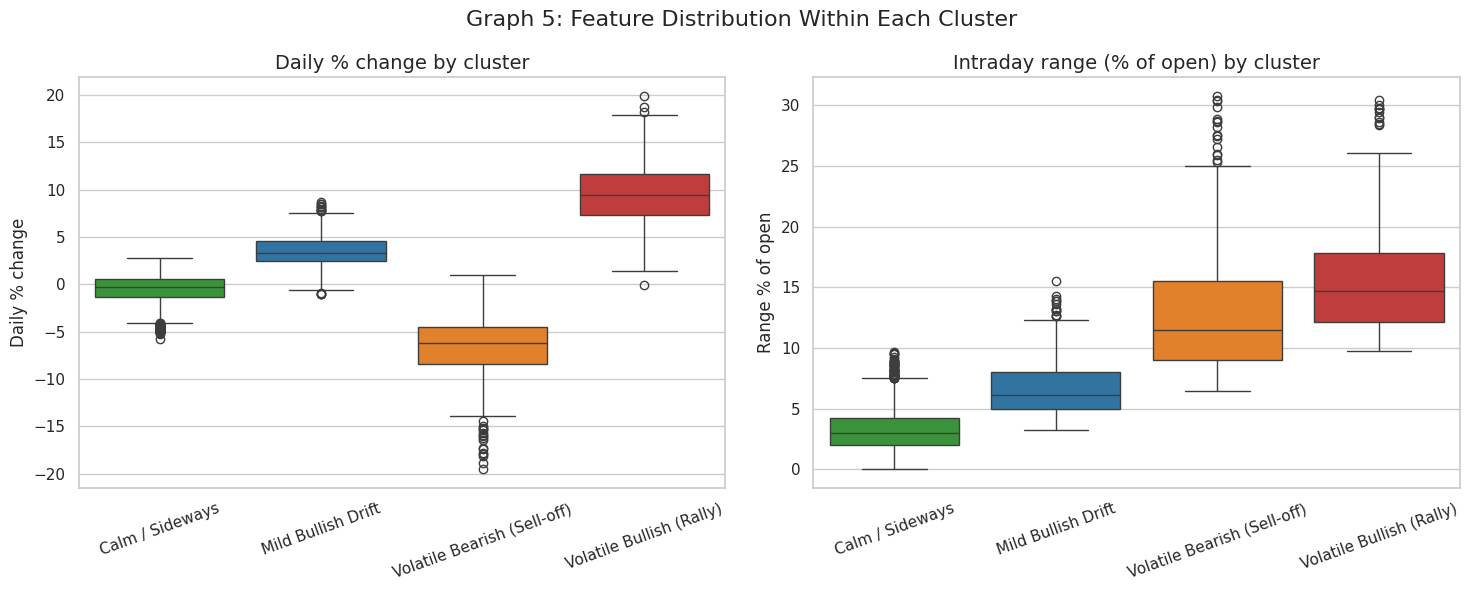

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(x='regime', y='daily_pct_change', data=data, order=order_names,
            palette=[PALETTE[r] for r in order_names], ax=axes[0])
axes[0].set_title('Daily % change by cluster', fontsize=14)
axes[0].set_xlabel(''); axes[0].set_ylabel('Daily % change')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(x='regime', y='range_pct', data=data, order=order_names,
            palette=[PALETTE[r] for r in order_names], ax=axes[1])
axes[1].set_title('Intraday range (% of open) by cluster', fontsize=14)
axes[1].set_xlabel(''); axes[1].set_ylabel('Range % of open')
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('Graph 5: Feature Distribution Within Each Cluster', fontsize=16)
plt.tight_layout()
plt.savefig(f"{OUT}/graph5_cluster_boxplots.png", dpi=150)
plt.show()

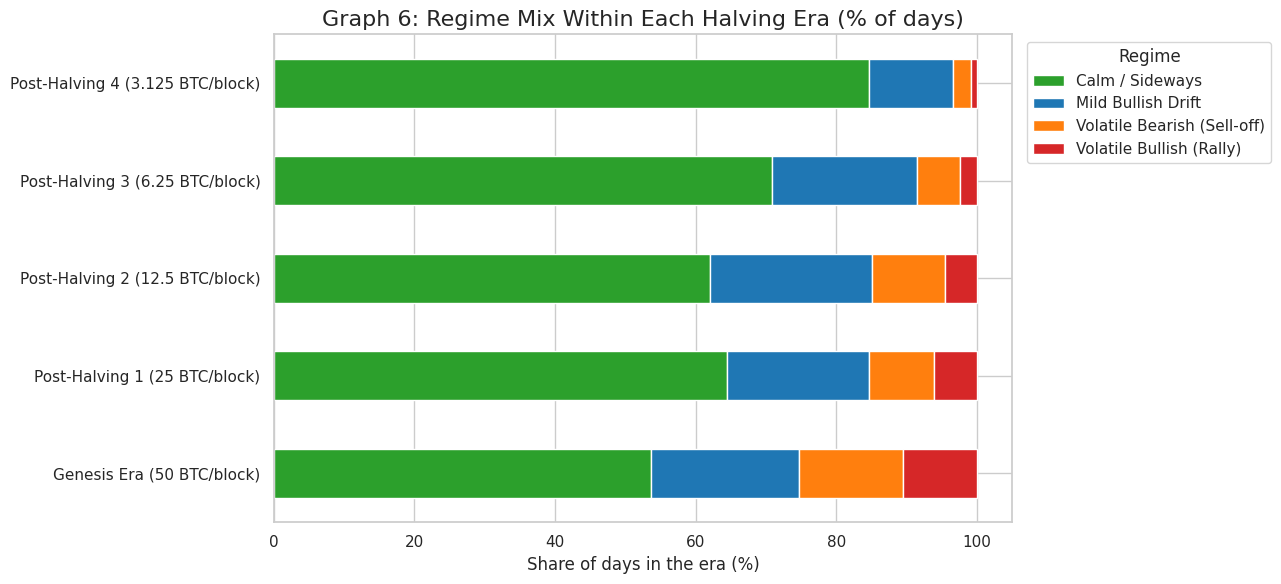

regime,Calm / Sideways,Mild Bullish Drift,Volatile Bearish (Sell-off),Volatile Bullish (Rally)
halving_era,,,,
Genesis Era (50 BTC/block),53.7,21.0,14.7,10.6
Post-Halving 1 (25 BTC/block),64.5,20.2,9.2,6.1
Post-Halving 2 (12.5 BTC/block),62.0,23.0,10.5,4.5
Post-Halving 3 (6.25 BTC/block),70.8,20.6,6.0,2.5
Post-Halving 4 (3.125 BTC/block),84.6,12.0,2.5,0.8


In [15]:
era_mix = pd.crosstab(data['halving_era'], data['regime'], normalize='index') * 100
era_mix = era_mix[[r for r in order_names if r in era_mix.columns]]

era_mix.plot(kind='barh', stacked=True, figsize=(13, 6),
             color=[PALETTE[r] for r in era_mix.columns])
plt.title('Graph 6: Regime Mix Within Each Halving Era (% of days)', fontsize=16)
plt.xlabel('Share of days in the era (%)', fontsize=12)
plt.ylabel('')
plt.legend(title='Regime', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUT}/graph6_regime_by_era.png", dpi=150)
plt.show()

era_mix.round(1)

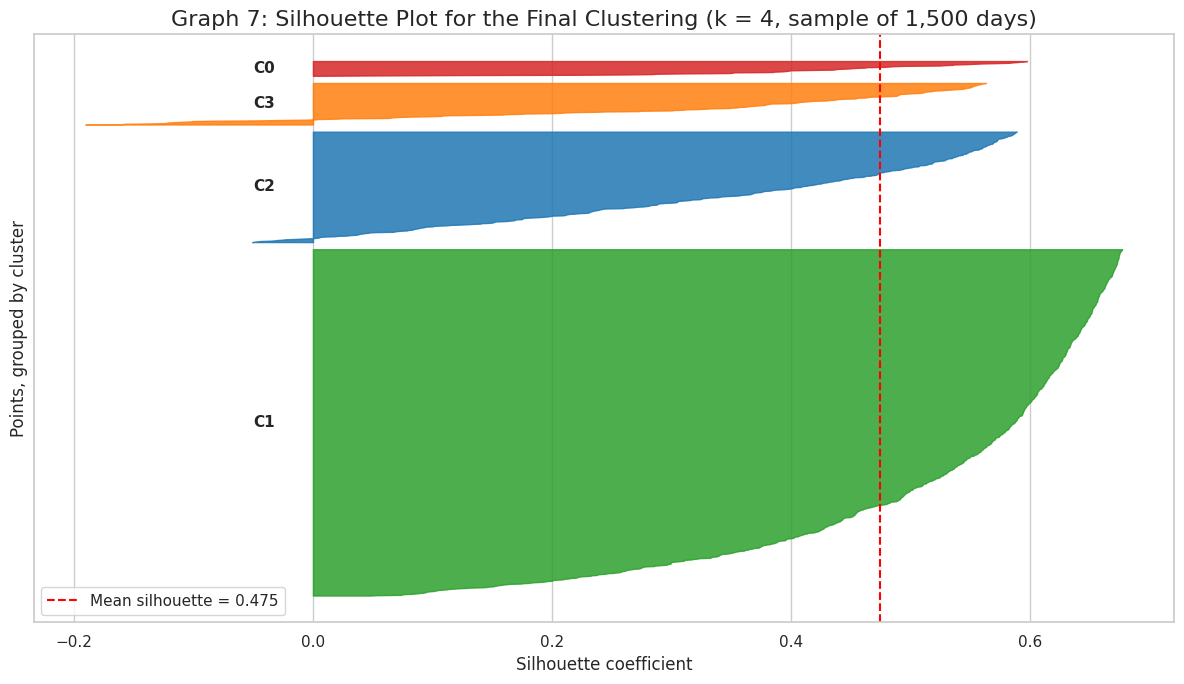

In [16]:
sil_vals = silhouette_samples_manual(X_sample, labels[sample_idx])
sil_labels = labels[sample_idx]
mean_sil = sil_vals.mean()

plt.figure(figsize=(12, 7))
y_lower = 0
for cl in order:
    vals = np.sort(sil_vals[sil_labels == cl])
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                      color=PALETTE[regime_names[int(cl)]], alpha=0.85)
    plt.text(-0.05, y_lower + len(vals) / 2, f"C{cl}", va='center', fontsize=11, fontweight='bold')
    y_lower = y_upper + 20
plt.axvline(mean_sil, color='red', linestyle='--', label=f'Mean silhouette = {mean_sil:.3f}')
plt.title('Graph 7: Silhouette Plot for the Final Clustering (k = 4, sample of 1,500 days)', fontsize=16)
plt.xlabel('Silhouette coefficient', fontsize=12)
plt.ylabel('Points, grouped by cluster', fontsize=12)
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/graph7_silhouette_plot.png", dpi=150)
plt.show()

## 8. Performance Matrix

Because clustering is unsupervised there is no accuracy to report, so the model is judged on
internal validity measures — all computed manually below:

| Measure | Meaning | Good value |
|---------|---------|-----------|
| **SSE (inertia)** | total squared distance of points to their centroid | lower |
| **Mean intra-cluster distance** | average distance of a member to its own centroid — cluster compactness | lower |
| **Silhouette coefficient** | cohesion vs separation, per cluster and overall | closer to 1 |
| **Davies–Bouldin index** | worst-case ratio of within-cluster spread to between-cluster separation | lower |
| **Calinski–Harabasz index** | between-cluster variance ÷ within-cluster variance | higher |

In [17]:
def davies_bouldin_manual(points, labels, centroids):
    k = len(centroids)
    spread = np.array([np.sqrt(((points[labels == i] - centroids[i]) ** 2).sum(axis=1)).mean()
                       for i in range(k)])
    sep = euclidean_distances(centroids, centroids)
    ratios = []
    for i in range(k):
        ratios.append(max((spread[i] + spread[j]) / sep[i, j] for j in range(k) if j != i))
    return float(np.mean(ratios))

def calinski_harabasz_manual(points, labels, centroids):
    n, k = len(points), len(centroids)
    overall = points.mean(axis=0)
    between = sum(len(points[labels == i]) * ((centroids[i] - overall) ** 2).sum() for i in range(k))
    within = compute_sse(points, labels, centroids)
    return float((between / (k - 1)) / (within / (n - k)))

rows = []
for rank, cl in enumerate(order):
    mask = labels == cl
    members_z = X[mask]
    d_own = np.sqrt(((members_z - centroids_z[cl]) ** 2).sum(axis=1))
    rows.append({
        'Cluster': f"C{cl}",
        'Regime': regime_names[int(cl)],
        'Size': int(mask.sum()),
        'Share %': round(mask.sum() / len(X) * 100, 2),
        'Centroid x (% chg)': round(centroids_raw[cl, 0], 2),
        'Centroid y (range %)': round(centroids_raw[cl, 1], 2),
        'Cluster SSE': round(float((d_own ** 2).sum()), 2),
        'Mean intra-dist': round(float(d_own.mean()), 3),
        'Max intra-dist': round(float(d_own.max()), 3),
        'Silhouette': round(float(sil_vals[sil_labels == cl].mean()), 3),
    })

perf = pd.DataFrame(rows)
print("PERFORMANCE MATRIX — per cluster")
print(perf.to_string(index=False))

dbi = davies_bouldin_manual(X, labels, centroids_z)
chi = calinski_harabasz_manual(X, labels, centroids_z)

print("\nPERFORMANCE MATRIX — overall")
print(f"  Number of clusters (k)      : {K}")
print(f"  Points clustered            : {len(X)}")
print(f"  Iterations to converge      : {iters}")
print(f"  Total SSE (z-space)         : {final_sse:.2f}")
print(f"  Mean silhouette coefficient : {mean_sil:.4f}")
print(f"  Davies-Bouldin index        : {dbi:.4f}   (lower is better)")
print(f"  Calinski-Harabasz index     : {chi:.2f}   (higher is better)")
perf

PERFORMANCE MATRIX — per cluster
Cluster                      Regime  Size  Share %  Centroid x (% chg)  Centroid y (range %)  Cluster SSE  Mean intra-dist  Max intra-dist  Silhouette
     C1             Calm / Sideways  3652    66.86               -0.48                  3.28      1110.30            0.485           1.517       0.532
     C2          Mild Bullish Drift  1097    20.08                3.46                  6.64       502.45            0.597           2.105       0.358
     C3 Volatile Bearish (Sell-off)   462     8.46               -6.68                 13.00      1032.54            1.273           4.248       0.320
     C0    Volatile Bullish (Rally)   251     4.60                9.58                 15.71       515.36            1.222           4.202       0.427

PERFORMANCE MATRIX — overall
  Number of clusters (k)      : 4
  Points clustered            : 5462
  Iterations to converge      : 12
  Total SSE (z-space)         : 3160.65
  Mean silhouette coefficient : 0.47

,Cluster,Regime,Size,Share %,Centroid x (% chg),Centroid y (range %),Cluster SSE,Mean intra-dist,Max intra-dist,Silhouette
0,C1,Calm / Sideways,3652,66.86,-0.48,3.28,1110.30,0.485,1.517,0.532
1,C2,Mild Bullish Drift,1097,20.08,3.46,6.64,502.45,0.597,2.105,0.358
2,C3,Volatile Bearish (Sell-off),462,8.46,-6.68,13.00,1032.54,1.273,4.248,0.320
3,C0,Volatile Bullish (Rally),251,4.60,9.58,15.71,515.36,1.222,4.202,0.427


In [18]:
summary = data.groupby('regime')[['daily_pct_change', 'range_pct', 'close']].agg(
    days=('daily_pct_change', 'size'),
    mean_change=('daily_pct_change', 'mean'),
    std_change=('daily_pct_change', 'std'),
    mean_range=('range_pct', 'mean'),
    max_range=('range_pct', 'max'))
summary = summary.reindex(order_names).round(3)
print("Descriptive profile of each regime")
print(summary.to_string())

print("\nMost extreme day in each regime:")
for regime in order_names:
    sub = data[data['regime'] == regime]
    row = sub.loc[sub['range_pct'].idxmax()]
    print(f"  {regime:<18} {row['date'].date()}  change {row['daily_pct_change']:+7.2f}%  range {row['range_pct']:6.2f}%")

summary

Descriptive profile of each regime
                             days  mean_change  std_change  mean_range  max_range
regime                                                                           
Calm / Sideways              3652       -0.479       1.506       3.284      9.666
Mild Bullish Drift           1097        3.456       1.697       6.641     15.553
Volatile Bearish (Sell-off)   462       -6.676       3.489      13.002     30.753
Volatile Bullish (Rally)      251        9.575       3.599      15.710     30.435

Most extreme day in each regime:
  Calm / Sideways    2012-02-08  change   -1.58%  range   9.67%
  Mild Bullish Drift 2013-07-04  change   +1.46%  range  15.55%
  Volatile Bearish (Sell-off) 2013-05-02  change   -8.70%  range  30.75%
  Volatile Bullish (Rally) 2011-02-04  change  +17.54%  range  30.43%


,days,mean_change,std_change,mean_range,max_range
regime,,,,,
Calm / Sideways,3652,-0.479,1.506,3.284,9.666
Mild Bullish Drift,1097,3.456,1.697,6.641,15.553
Volatile Bearish (Sell-off),462,-6.676,3.489,13.002,30.753
Volatile Bullish (Rally),251,9.575,3.599,15.710,30.435


## 9. Cluster Analysis Report

**Setup.** 5,534 cleaned trading days (Feb 2011 – Mar 2026) were described by two
scale-free features — the day's percentage move and its intraday range as a percentage of the
open. 72 shock days (1.30%) were separated out first, and the remaining **5,462 days** were
clustered with a hand-written K-Means at k = 4, restarted 10 times, keeping the run with the
lowest SSE (3160.65).

### 9.1 The four regimes

| Cluster | Regime | Centroid (change %, range %) | Days | Share | Silhouette |
|---|---|---|---|---|---|
| C1 | **Calm / Sideways** | (−0.48, 3.28) | 3,652 | 66.9% | 0.532 |
| C2 | **Mild Bullish Drift** | (+3.46, 6.64) | 1,097 | 20.1% | 0.358 |
| C3 | **Volatile Bearish (Sell-off)** | (−6.68, 13.00) | 462 | 8.5% | 0.320 |
| C0 | **Volatile Bullish (Rally)** | (+9.58, 15.71) | 251 | 4.6% | 0.427 |

**C1 — Calm / Sideways (two days out of every three).** The average day in this cluster barely
moves (−0.48%) and swings only 3.3% between its high and low. This is the market's resting
state: no cluster member exceeds a 9.7% intraday range. It is also the tightest cluster
(mean intra-cluster distance 0.485, the best silhouette of the four at 0.532).

**C2 — Mild Bullish Drift (one day in five).** A modest, orderly gain (+3.46%) on a 6.6% range.
This is the cluster that carries the long bull phases: steady upward days with no panic in them.
Its low silhouette (0.358) is expected — it sits directly between the calm core and the rally
cluster on the scatter plot, so many of its members are genuinely borderline days.

**C3 — Volatile Bearish / Sell-off (8.5% of days).** Average −6.68% on a 13.0% range. These are
the panic days: the price falls hard and swings widely inside the session.

**C0 — Volatile Bullish / Rally (4.6% of days).** Average +9.58% on a 15.71% range — the largest
average move of any cluster. Rallies are rarer than sell-offs (251 days vs 462) but individually
larger, which is the clearest asymmetry the clustering exposes.

### 9.2 What the clusters say about the market

1. **Bitcoin is calm far more often than its reputation suggests.** 87% of days fall in the two
   low-volatility clusters (C1 + C2). The turbulence that dominates the headlines lives in the
   13% of days that make up C0 and C3.
2. **The market has matured.** The calm cluster's share of days rises steadily across the halving
   eras — 53.7% in the Genesis era, 64.5%, 62.0%, 70.8% and 84.6% in the current
   (3.125 BTC/block) era. Over the same span the sell-off cluster falls from 14.7% to 2.5% of
   days and the rally cluster from 10.6% to 0.8%. Per calendar year, turbulent days fall from
   39.7% (2011) to 2.2% (2023) and 2.7% (2025).
3. **Turbulence lines up with the known boom–bust cycles.** In Graph 4 the orange and red points
   are not spread evenly; they bunch around the 2013 run-up, the 2017–18 peak and crash, the March
   2020 COVID drop and the 2021 cycle — the same cycles named in the problem statement, recovered
   here without being told about them.
4. **Falls and rallies are not mirror images.** Sell-off days are almost twice as common as rally
   days, but the average rally is larger (+9.58% vs −6.68%). Downside turbulence is frequent;
   upside turbulence is rarer and sharper.
5. **The shock days are their own story.** The 72 excluded days concentrate in 2011 (27) and
   2013–14 (30) — the Mt. Gox era, when a single exchange's prints could move the recorded price
   by hundreds of percent. Their removal is what allowed the four regimes to form; left in, one
   cluster collapsed onto a single day (26 Feb 2014, +336.8% on a 378.7% range).

### 9.3 Limitations

- K-Means assumes roughly spherical, similar-sized clusters. The real data is a continuous
  V-shaped cloud (Graph 3), so the cluster boundaries are cuts through a continuum rather than
  natural gaps — which is why the silhouette scores are moderate rather than high.
- The result depends on the initial centroids; restarts mitigate this but do not remove it.
- Only two features are used. Volume, macro news and on-chain activity would separate the
  regimes further.
- Clustering describes the past; it does not predict tomorrow's regime on its own.

## 10. Conclusion

K-Means was implemented from first principles — k-means++ seeding, Euclidean assignment,
centroid update, convergence test, SSE, silhouette and Davies–Bouldin — with no clustering
library, and applied to 5,462 Bitcoin trading days.

The algorithm converged in 12 iterations to an SSE of 3160.65 and produced four interpretable
market regimes: a dominant calm state (66.9% of days), a mild bullish drift (20.1%), volatile
sell-offs (8.5%) and volatile rallies (4.6%). The clustering scores a mean silhouette of 0.4746,
a Davies–Bouldin index of 0.7487 and a Calinski–Harabasz index of 4468.75; k = 3 scores marginally
better on silhouette, but k = 4 was retained because separating volatile-up from volatile-down days
is what makes the output usable as a risk signal.

Two findings stand out: Bitcoin's volatility is concentrated in a small minority of days, and the
share of those days has fallen steadily across every halving era — quantitative evidence for the
maturation the case study set out to test. The experiment also demonstrated K-Means' best-known
weakness in practice: a single extreme day (26 Feb 2014) was enough to consume an entire cluster
until the outliers identified in Experiment 5 were handled explicitly.